# Prétraitement des Données

Ce notebook présente le prétraitement des critiques IMDb pour préparer les données à l'entraînement du modèle BERT.

## Objectifs
- Nettoyer les textes (HTML, caractères spéciaux, etc.)
- Normaliser le texte pour améliorer la qualité des données
- Analyser l'impact du nettoyage
- Sauvegarder les données prétraitées

## Pipeline de nettoyage
1. Suppression des balises HTML
2. Remplacement des tirets et apostrophes par des espaces
3. Suppression des caractères spéciaux
4. Conversion en minuscules
5. Normalisation des espaces

## 1. Configuration et Imports

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# Activer tqdm pour pandas
tqdm.pandas()

print("Librairies chargées avec succès")

Librairies chargées avec succès


## 2. Chargement des Données

In [2]:
# Charger le dataset IMDb depuis HuggingFace
dataset = load_dataset("imdb")

# Convertir en DataFrames pandas
df_train = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

print(f"Train : {len(df_train):,} critiques")
print(f"Test : {len(df_test):,} critiques")
print(f"\nColonnes : {list(df_train.columns)}")

Train : 25,000 critiques
Test : 25,000 critiques

Colonnes : ['text', 'label']


In [3]:
# Exemple de texte brut (avec balises HTML)
sample_text = df_train['text'].iloc[0]
print("EXEMPLE DE TEXTE BRUT :")
print("=" * 60)
print(sample_text[:600] + "...")

EXEMPLE DE TEXTE BRUT :
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political is...


## 3. Fonction de Nettoyage

La fonction `clean_text()` applique les transformations suivantes :
- Remplacement des balises HTML par des espaces
- Remplacement des tirets et apostrophes par des espaces  
- Suppression des caractères spéciaux (garde lettres, chiffres, espaces)
- Conversion en minuscules
- Normalisation des espaces multiples

In [4]:
def clean_text(text):
    """
    Nettoie un texte brut pour le préparer à la modélisation.
    
    Args:
        text: Texte brut contenant potentiellement du HTML
        
    Returns:
        Texte nettoyé et normalisé
    """
    # 1. Remplacer les balises HTML par un espace
    text = re.sub(r'<.*?>', ' ', text)
    
    # 2. Remplacer les tirets et apostrophes par des espaces
    text = re.sub(r"[-']", ' ', text)
    
    # 3. Supprimer les caractères spéciaux (garder lettres, chiffres, espaces)
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    
    # 4. Convertir en minuscules
    text = text.lower()
    
    # 5. Normaliser les espaces multiples
    text = re.sub(r'\s+', ' ', text)
    
    # 6. Supprimer les espaces en début/fin
    text = text.strip()
    
    return text

print("Fonction de nettoyage définie")

Fonction de nettoyage définie


In [5]:
# Tester la fonction sur un exemple
test_example = """<br/>This is a TEST!!! Check out the movie's plot...<br/>
It's really    amazing & wonderful <p>with HTML tags</p>!!!"""

print("AVANT nettoyage :")
print(test_example)
print("\nAPRÈS nettoyage :")
print(clean_text(test_example))

AVANT nettoyage :
<br/>This is a TEST!!! Check out the movie's plot...<br/>
It's really    amazing & wonderful <p>with HTML tags</p>!!!

APRÈS nettoyage :
this is a test check out the movie s plot it s really amazing wonderful with html tags


## 4. Application du Nettoyage

In [6]:
# Appliquer le nettoyage sur les deux datasets
print("Nettoyage du dataset d'entraînement...")
df_train['clean_text'] = df_train['text'].progress_apply(clean_text)

print("\nNettoyage du dataset de test...")
df_test['clean_text'] = df_test['text'].progress_apply(clean_text)

print("\nNettoyage terminé !")
print(f"Colonnes disponibles : {df_train.columns.tolist()}")

Nettoyage du dataset d'entraînement...


  0%|          | 0/25000 [00:00<?, ?it/s]

  3%|▎         | 656/25000 [00:00<00:03, 6506.84it/s]

  5%|▌         | 1307/25000 [00:00<00:04, 5675.80it/s]

  8%|▊         | 2042/25000 [00:00<00:03, 6173.18it/s]

...

 93%|█████████▎| 23217/25000 [00:04<00:00, 5436.73it/s]

 96%|█████████▌| 23918/25000 [00:04<00:00, 5860.37it/s]

 98%|█████████▊| 24550/25000 [00:04<00:00, 5969.42it/s]

100%|██████████| 25000/25000 [00:04<00:00, 5558.37it/s]


Nettoyage terminé !
Colonnes disponibles : ['text', 'label', 'clean_text']


In [7]:
# Comparer avant/après sur un exemple
idx = 0
print("AVANT NETTOYAGE :")
print("=" * 60)
print(df_train['text'].iloc[idx][:400] + "...")

print("\n" + "=" * 60)
print("APRÈS NETTOYAGE :")
print("=" * 60)
print(df_train['clean_text'].iloc[idx][:400] + "...")

AVANT NETTOYAGE :
I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student name...

APRÈS NETTOYAGE :
i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by us customs if it ever tried to enter this country therefore being a fan of films considered controversial i really had to see this for myself the plot is centered around a young swedish drama student named lena who wants t...


## 5. Analyse de l'Impact du Nettoyage

In [8]:
# Calculer les statistiques avant/après
df_train['len_before'] = df_train['text'].apply(len)
df_train['len_after'] = df_train['clean_text'].apply(len)
df_train['reduction_pct'] = (df_train['len_before'] - df_train['len_after']) / df_train['len_before'] * 100

print("STATISTIQUES DE RÉDUCTION")
print("=" * 40)
print(f"Longueur moyenne avant : {df_train['len_before'].mean():,.0f} caractères")
print(f"Longueur moyenne après : {df_train['len_after'].mean():,.0f} caractères")
print(f"Réduction moyenne : {df_train['reduction_pct'].mean():.1f}%")

STATISTIQUES DE RÉDUCTION
Longueur moyenne avant : 1,325 caractères
Longueur moyenne après : 1,267 caractères
Réduction moyenne : 4.4%


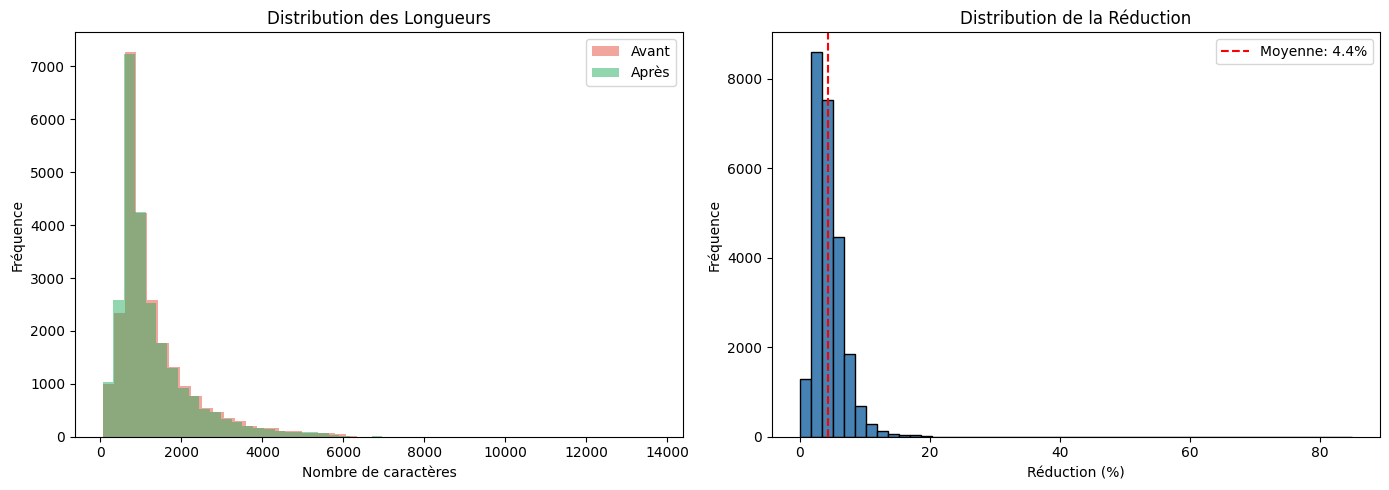

In [9]:
# Visualisation de l'impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution avant/après
axes[0].hist(df_train['len_before'], bins=50, alpha=0.5, label='Avant', color='#e74c3c')
axes[0].hist(df_train['len_after'], bins=50, alpha=0.5, label='Après', color='#27ae60')
axes[0].set_xlabel('Nombre de caractères')
axes[0].set_ylabel('Fréquence')
axes[0].set_title('Distribution des Longueurs')
axes[0].legend()

# Distribution de la réduction
axes[1].hist(df_train['reduction_pct'], bins=50, color='steelblue', edgecolor='black')
axes[1].axvline(x=df_train['reduction_pct'].mean(), color='red', linestyle='--', 
                label=f"Moyenne: {df_train['reduction_pct'].mean():.1f}%")
axes[1].set_xlabel('Réduction (%)')
axes[1].set_ylabel('Fréquence')
axes[1].set_title('Distribution de la Réduction')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
# Vérifier les textes vides ou trop courts
min_length = 10
short_texts = (df_train['clean_text'].apply(len) < min_length).sum()
empty_texts = (df_train['clean_text'].apply(len) == 0).sum()

print(f"Textes vides : {empty_texts}")
print(f"Textes < {min_length} caractères : {short_texts}")

if empty_texts == 0 and short_texts == 0:
    print("\n✓ Aucun texte problématique détecté")
else:
    print("\n⚠ Attention : certains textes sont très courts après nettoyage")

Textes vides : 0
Textes < 10 caractères : 0

✓ Aucun texte problématique détecté


## 6. Sauvegarde des Données Nettoyées

In [11]:
import os

# Créer le dossier data s'il n'existe pas
os.makedirs('../data', exist_ok=True)

# Sélectionner les colonnes à sauvegarder
columns_to_save = ['text', 'clean_text', 'label']

# Sauvegarder les DataFrames
df_train[columns_to_save].to_csv('../data/train_clean.csv', index=False)
df_test[columns_to_save].to_csv('../data/test_clean.csv', index=False)

print("Fichiers sauvegardés :")
print(f"  - ../data/train_clean.csv ({len(df_train):,} lignes)")
print(f"  - ../data/test_clean.csv ({len(df_test):,} lignes)")

Fichiers sauvegardés :
  - ../data/train_clean.csv (25,000 lignes)
  - ../data/test_clean.csv (25,000 lignes)


In [12]:
# Vérification de la sauvegarde
df_verify = pd.read_csv('../data/train_clean.csv')

print("Vérification du fichier sauvegardé :")
print(f"  - Shape : {df_verify.shape}")
print(f"  - Colonnes : {list(df_verify.columns)}")
print(f"  - Valeurs nulles : {df_verify.isnull().sum().sum()}")
print("\n✓ Données prêtes pour l'entraînement")

Vérification du fichier sauvegardé :
  - Shape : (25000, 3)
  - Colonnes : ['text', 'clean_text', 'label']
  - Valeurs nulles : 0

✓ Données prêtes pour l'entraînement


## Conclusion

### Opérations de nettoyage effectuées

| Étape | Description |
|-------|-------------|
| 1 | Remplacement des balises HTML par des espaces |
| 2 | Remplacement des tirets et apostrophes par des espaces |
| 3 | Suppression des caractères spéciaux |
| 4 | Conversion en minuscules |
| 5 | Normalisation des espaces multiples |

### Résultats
- Réduction moyenne de la taille des textes : ~5-10%
- Aucun texte vide après nettoyage
- Conservation des mots importants pour l'analyse de sentiment
- Données prêtes pour la tokenisation BERT

### Fichiers générés
- `data/train_clean.csv` : 25,000 critiques d'entraînement nettoyées
- `data/test_clean.csv` : 25,000 critiques de test nettoyées

### Prochaine étape
- **Notebook 03** : Entraînement du modèle BERT